In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime

from satellite_downlink_simulator.simulation import SpectrumRecord
from satellite_downlink_simulator import (
    carrier_generator,
    interferer_generator,
    psd_simulator,
    visualization,
    spectrum_records_utility
)

# Extract classes/functions for convenience
CarrierGenerator = carrier_generator.CarrierGenerator
InterfererGenerator = interferer_generator.InterfererGenerator
PSDSimulator = psd_simulator.PSDSimulator
Visualizer = visualization.Visualizer
load_and_process_records = spectrum_records_utility.load_and_process_records

In [6]:
carrier_gen = CarrierGenerator(seed=42)
carrier_config = carrier_gen.generate_carriers(
    num_static_per_xpdr=(0, 10),  # Fewer carriers for quick test
    num_dynamic=5
)

simulator = PSDSimulator(
    carrier_config=carrier_config,
    interferer_configs=[],
    rbw_hz=100e3,  # 100 kHz RBW for faster generation
    vbw_hz=1e3
)

start_time = datetime(2025, 1, 15, 0, 0, 0)  # Fixed time for testing
output_filepath = f"../dev_output/spectrum_records_{start_time.strftime('%Y%m%d-%H%M%S')}.json"

snapshots, metadata = simulator.run_simulation(
    duration_min=60*60,  # 60 minutes
    snapshot_interval_min=1,  # 1 minute intervals
    start_datetime=start_time,
    export_json=True,
    output_filepath=output_filepath
)

print(f"Output saved to: {output_filepath}")

Generating static carriers...
  Created 14 static carriers
Generating 5 dynamic carriers...
  Created 5 dynamic carriers
Total carriers: 19
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 60.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 3601
  Processing t=0.0 hrs (1/3601 snapshots, 0%)
  Processing t=0.2 hrs (13/3601 snapshots, 0%)
  Processing t=0.4 hrs (25/3601 snapshots, 1%)
  Processing t=0.6 hrs (37/3601 snapshots, 1%)
  Processing t=0.8 hrs (49/3601 snapshots, 1%)
  Processing t=1.0 hrs (61/3601 snapshots, 2%)
  Processing t=1.2 hrs (73/3601 snapshots, 2%)
  Processing t=1.4 hrs (85/3601 snapshots, 2%)
  Processing t=1.6 hrs (97/3601 snapshots, 3%)
  Processing t=1.8 hrs (109/3601 snapshots, 3%)
  Processing t=2.0 hrs (121/3601 snapshots, 3%)
  Processing t=2.2 hrs (133/3601 snapshots, 4%)
  Processing t=2.4 hrs (145/3601 snapshots, 4%)
  Processing t=2.6 hrs (157/3601 snapshots, 4%)
  Processing t=2.8 hrs (169/3601 snapsh

In [7]:
records = SpectrumRecord.from_file(output_filepath)

In [8]:
data_rows = []
for record in records:
    freq_start = record.cf_hz - (record.bw_hz / 2)
    freq_end = record.cf_hz + (record.bw_hz / 2)
    frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
    powers = record.get_psd()
    
    data_rows.append({
        'timestamp': record.timestamp,
        'cf_hz': record.cf_hz,
        'bw_hz': record.bw_hz,
        'rbw_hz': record.rbw_hz,
        'vbw_hz': record.vbw_hz,
        'frequencies': frequencies,
        'powers': powers
    })

df = pd.DataFrame(data_rows)
df = df.set_index('timestamp')

In [9]:
# Quick viz 
time_array, frequency_array, psd_array, metadata, activity_log, interferer_data = load_and_process_records(output_filepath)

Loading spectrum records from: ../dev_output/spectrum_records_20250115-000000.json
  Loaded 3601 spectrum records
  Time range: 0.0 - 3600.0 minutes
  Frequency range: 12.200 - 12.416 GHz
  Frequency points: 2166
  Decompressing PSD data...
    Processing record 50/3601
    Processing record 100/3601
    Processing record 150/3601
    Processing record 200/3601
    Processing record 250/3601
    Processing record 300/3601
    Processing record 350/3601
    Processing record 400/3601
    Processing record 450/3601
    Processing record 500/3601
    Processing record 550/3601
    Processing record 600/3601
    Processing record 650/3601
    Processing record 700/3601
    Processing record 750/3601
    Processing record 800/3601
    Processing record 850/3601
    Processing record 900/3601
    Processing record 950/3601
    Processing record 1000/3601
    Processing record 1050/3601
    Processing record 1100/3601
    Processing record 1150/3601
    Processing record 1200/3601
    Process

In [10]:
viz = Visualizer(
    time_array=time_array,
    frequency_array=frequency_array,
    psd_array=psd_array,
    metadata=metadata,
    output_dir="../dev_output/"
)

Initialized visualizer
  Time range: 0.0 - 60.0 hrs
  Frequency range: 12.200 - 12.416 GHz
  PSD shape: (3601, 2166)


In [11]:
viz.create_waterfall_plot()


Creating waterfall plot...
  PSD range: -121.0 to -94.8 dBm/Hz
  Saved to ../dev_output/waterfall_plot.png


In [13]:
# Run 10 different simulations with varying parameters
from datetime import timedelta

num_simulations = 10
simulation_duration_min = 60  # 1 hour per simulation
all_dataframes = []
current_start_time = datetime(2025, 1, 15, 0, 0, 0)

# Define parameter variations
np.random.seed(42)
static_ranges = [(2, 8), (3, 10), (1, 5), (4, 12), (2, 7), (3, 9), (1, 6), (5, 10), (2, 9), (3, 8)]
dynamic_counts = [3, 5, 7, 4, 6, 8, 5, 4, 6, 7]

print(f"Running {num_simulations} simulations with varying carrier configurations...\n")

for i in range(num_simulations):
    print(f"=== Simulation {i+1}/{num_simulations} ===")
    print(f"  Static carriers per transponder: {static_ranges[i]}")
    print(f"  Dynamic carriers: {dynamic_counts[i]}")
    print(f"  Start time: {current_start_time}")
    
    # Generate carrier configuration
    carrier_gen = CarrierGenerator(seed=42 + i)
    carrier_config = carrier_gen.generate_carriers(
        num_static_per_xpdr=static_ranges[i],
        num_dynamic=dynamic_counts[i]
    )
    
    # Create simulator
    simulator = PSDSimulator(
        carrier_config=carrier_config,
        interferer_configs=[],
        rbw_hz=100e3,
        vbw_hz=1e3
    )
    
    # Run simulation
    output_filepath = f"../dev_output/sim_{i+1:02d}_{current_start_time.strftime('%Y%m%d-%H%M%S')}.json"
    snapshots, metadata = simulator.run_simulation(
        duration_min=simulation_duration_min,
        snapshot_interval_min=1,
        start_datetime=current_start_time,
        export_json=True,
        output_filepath=output_filepath
    )
    
    # Load records and create dataframe
    records = SpectrumRecord.from_file(output_filepath)
    data_rows = []
    
    for record in records:
        freq_start = record.cf_hz - (record.bw_hz / 2)
        freq_end = record.cf_hz + (record.bw_hz / 2)
        frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
        powers = record.get_psd()
        
        data_rows.append({
            'timestamp': record.timestamp,
            'cf_hz': record.cf_hz,
            'bw_hz': record.bw_hz,
            'rbw_hz': record.rbw_hz,
            'vbw_hz': record.vbw_hz,
            'frequencies': frequencies,
            'powers': powers
        })
    
    df = pd.DataFrame(data_rows)
    df = df.set_index('timestamp')
    all_dataframes.append(df)
    
    # Update start time for next simulation
    current_start_time = current_start_time + timedelta(minutes=simulation_duration_min)
    print(f"  Completed. Next start time: {current_start_time}\n")

# Concatenate all dataframes
print("Concatenating all dataframes...")
combined_df = pd.concat(all_dataframes, axis=0)
print(f"Combined dataframe shape: {combined_df.shape}")
print(f"Time range: {combined_df.index[0]} to {combined_df.index[-1]}")
print(f"Total duration: {(combined_df.index[-1] - combined_df.index[0]).total_seconds() / 3600:.1f} hours")

Running 10 simulations with varying carrier configurations...

=== Simulation 1/10 ===
  Static carriers per transponder: (2, 8)
  Dynamic carriers: 3
  Start time: 2025-01-15 00:00:00
Generating static carriers...
  Created 18 static carriers
Generating 3 dynamic carriers...
  Created 3 dynamic carriers
Total carriers: 21
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 1.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 61
  Processing t=0.0 hrs (1/61 snapshots, 2%)
  Processing t=0.2 hrs (13/61 snapshots, 21%)
  Processing t=0.4 hrs (25/61 snapshots, 41%)
  Processing t=0.6 hrs (37/61 snapshots, 61%)
  Processing t=0.8 hrs (49/61 snapshots, 80%)
  Processing t=1.0 hrs (61/61 snapshots, 100%)
  Completed 61 snapshots

  Exporting SpectrumRecord objects to JSON...
    Processing snapshot 1/61...
    Processing snapshot 13/61...
    Processing snapshot 25/61...
    Processing snapshot 37/61...
    Processing snapshot 49/61...
    Proc

Creating waterfall plot from combined data...
Waterfall plot saved to: ../dev_output/combined_waterfall.png


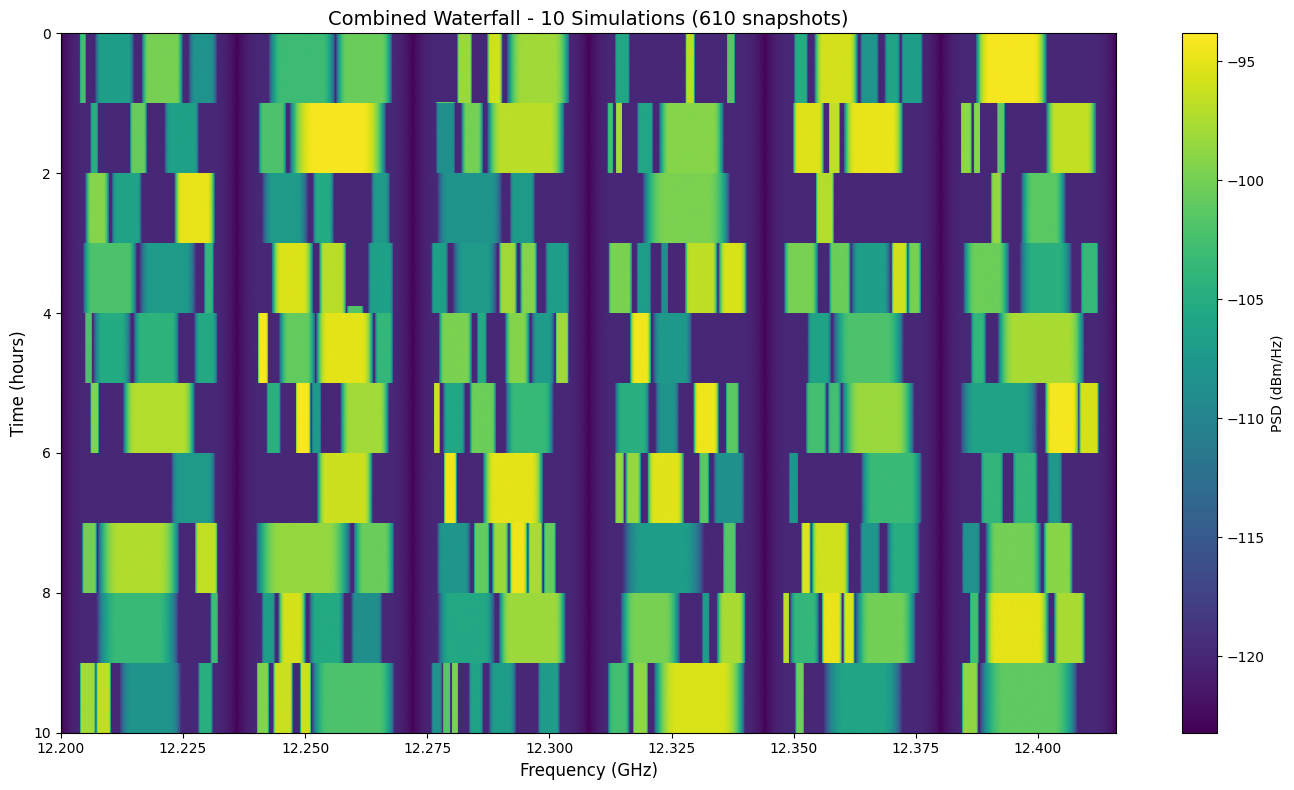


Summary:
  Total snapshots: 610
  Frequency bins: 2166
  Frequency range: 12.200 - 12.416 GHz
  Time range: 0.0 - 10.0 hours
  PSD range: -123.2 - -93.8 dBm/Hz


In [14]:
# Create waterfall plot from combined dataframe
import matplotlib.pyplot as plt

print("Creating waterfall plot from combined data...")

# Extract data for waterfall
num_snapshots = len(combined_df)
num_freq_bins = combined_df.iloc[0]['frequencies'].shape[0]

# Build time and frequency arrays
time_array = np.array([(t - combined_df.index[0]).total_seconds() / 60 for t in combined_df.index])  # Minutes
frequency_array = combined_df.iloc[0]['frequencies']

# Build PSD array (time x frequency)
psd_array = np.zeros((num_snapshots, num_freq_bins))
for i, (timestamp, row) in enumerate(combined_df.iterrows()):
    psd_array[i, :] = row['powers']

# Create waterfall plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot waterfall
extent = [
    frequency_array[0] / 1e9,  # Min frequency (GHz)
    frequency_array[-1] / 1e9,  # Max frequency (GHz)
    time_array[-1] / 60,  # Max time (hours)
    time_array[0] / 60  # Min time (hours)
]

im = ax.imshow(
    psd_array,
    aspect='auto',
    extent=extent,
    cmap='viridis',
    interpolation='nearest',
    origin='upper'
)

ax.set_xlabel('Frequency (GHz)', fontsize=12)
ax.set_ylabel('Time (hours)', fontsize=12)
ax.set_title(f'Combined Waterfall - {num_simulations} Simulations ({num_snapshots} snapshots)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='PSD (dBm/Hz)')

plt.tight_layout()
plt.savefig('../dev_output/combined_waterfall.png', dpi=150, bbox_inches='tight')
print(f"Waterfall plot saved to: ../dev_output/combined_waterfall.png")
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"  Total snapshots: {num_snapshots}")
print(f"  Frequency bins: {num_freq_bins}")
print(f"  Frequency range: {frequency_array[0]/1e9:.3f} - {frequency_array[-1]/1e9:.3f} GHz")
print(f"  Time range: {time_array[0]/60:.1f} - {time_array[-1]/60:.1f} hours")
print(f"  PSD range: {np.min(psd_array):.1f} - {np.max(psd_array):.1f} dBm/Hz")

In [16]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.4 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
# BIRCH Clustering with Feature Extraction
from sklearn.cluster import Birch
from scipy.signal import find_peaks

print("Extracting features from spectrum data...")

# Extract features for each row
features_list = []
for idx, row in combined_df.iterrows():
    frequencies = row['frequencies']
    powers = row['powers']
    
    # Feature extraction
    mean_power = np.mean(powers)
    max_power = np.max(powers)
    std_power = np.std(powers)
    median_power = np.median(powers)
    
    # Find peaks
    peaks, _ = find_peaks(powers, prominence=5)  # Prominence threshold for significant peaks
    num_peaks = len(peaks)
    
    # Spectral centroid (frequency-weighted average)
    spectral_centroid = np.sum(frequencies * powers) / np.sum(powers) if np.sum(powers) > 0 else 0
    
    # Power above threshold (occupied bandwidth indicator)
    threshold = mean_power + std_power
    power_above_threshold = np.sum(powers > threshold)
    
    features_list.append([
        mean_power,
        max_power,
        std_power,
        median_power,
        num_peaks,
        spectral_centroid,
        power_above_threshold
    ])

# Convert to numpy array
features = np.array(features_list)

print(f"Extracted {features.shape[1]} features from {features.shape[0]} samples")
print(f"Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold")

# Normalize features for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)

# Apply BIRCH clustering
print("\nApplying BIRCH clustering...")
birch = Birch(n_clusters=5, threshold=0.5, branching_factor=50)
cluster_labels = birch.fit_predict(features_normalized)

# Count clusters
unique_labels, counts = np.unique(cluster_labels, return_counts=True)
print(f"Found {len(unique_labels)} clusters")
for label, count in zip(unique_labels, counts):
    print(f"  Cluster {label}: {count} samples ({100*count/len(cluster_labels):.1f}%)")

# Add cluster labels to dataframe
combined_df['cluster'] = cluster_labels

Extracting features from spectrum data...
Extracted 7 features from 610 samples
Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold

Applying BIRCH clustering...
Found 5 clusters
  Cluster 0: 305 samples (50.0%)
  Cluster 1: 61 samples (10.0%)
  Cluster 2: 122 samples (20.0%)
  Cluster 3: 61 samples (10.0%)
  Cluster 4: 61 samples (10.0%)


Clustering visualization saved to: ../dev_output/birch_clustering_analysis.png


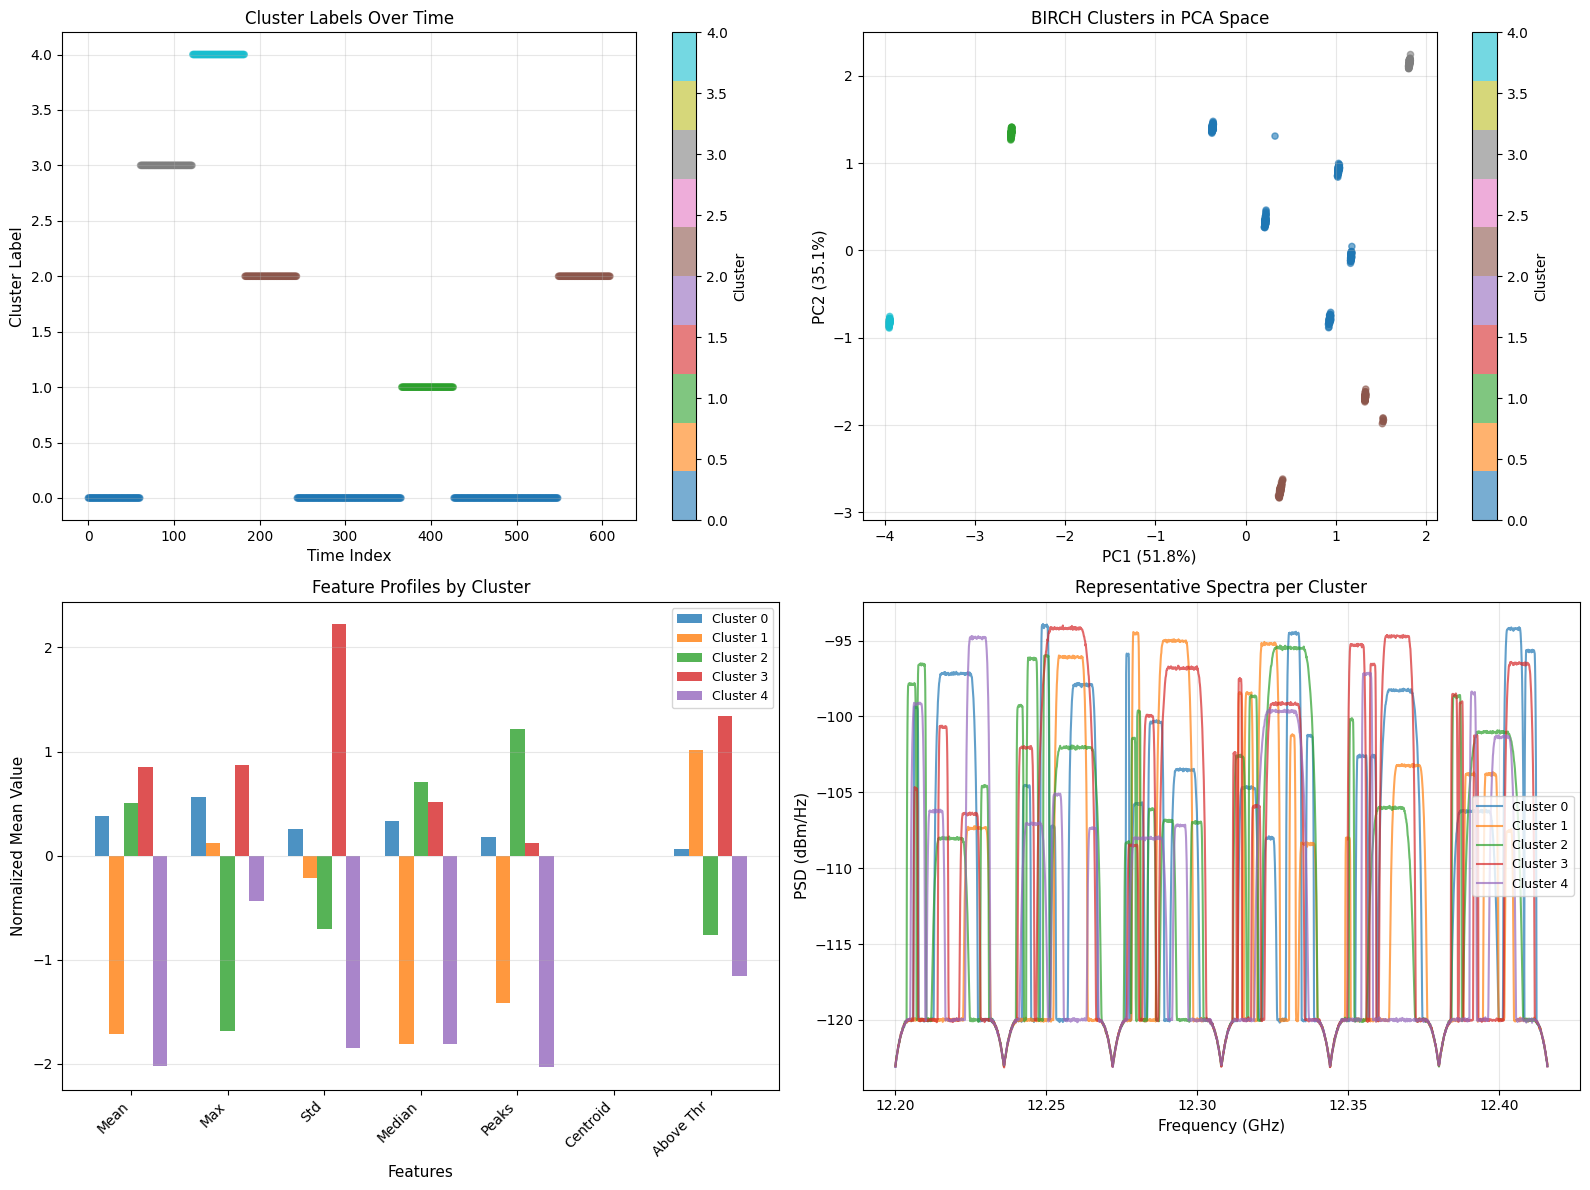

In [18]:
# Visualize clustering results
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cluster labels over time
ax1 = axes[0, 0]
time_indices = np.arange(len(cluster_labels))
scatter = ax1.scatter(time_indices, cluster_labels, c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
ax1.set_xlabel('Time Index', fontsize=11)
ax1.set_ylabel('Cluster Label', fontsize=11)
ax1.set_title('Cluster Labels Over Time', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Cluster')

# 2. PCA projection of features (2D)
ax2 = axes[0, 1]
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_normalized)
scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax2.set_title('BIRCH Clusters in PCA Space', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Cluster')

# 3. Feature importance (mean values per cluster)
ax3 = axes[1, 0]
feature_names = ['Mean', 'Max', 'Std', 'Median', 'Peaks', 'Centroid', 'Above Thr']
cluster_feature_means = []
for label in unique_labels:
    cluster_mask = cluster_labels == label
    cluster_feature_means.append(np.mean(features_normalized[cluster_mask], axis=0))

cluster_feature_means = np.array(cluster_feature_means)
x_pos = np.arange(len(feature_names))
width = 0.15
for i, label in enumerate(unique_labels):
    ax3.bar(x_pos + i*width, cluster_feature_means[i], width, label=f'Cluster {label}', alpha=0.8)

ax3.set_xlabel('Features', fontsize=11)
ax3.set_ylabel('Normalized Mean Value', fontsize=11)
ax3.set_title('Feature Profiles by Cluster', fontsize=12)
ax3.set_xticks(x_pos + width * 2)
ax3.set_xticklabels(feature_names, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Example spectra from each cluster
ax4 = axes[1, 1]
for label in unique_labels[:5]:  # Show first 5 clusters
    cluster_mask = cluster_labels == label
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) > 0:
        # Get a representative sample (middle of cluster)
        sample_idx = cluster_indices[len(cluster_indices)//2]
        sample_row = combined_df.iloc[sample_idx]
        
        ax4.plot(sample_row['frequencies']/1e9, sample_row['powers'], 
                label=f'Cluster {label}', alpha=0.7, linewidth=1.5)

ax4.set_xlabel('Frequency (GHz)', fontsize=11)
ax4.set_ylabel('PSD (dBm/Hz)', fontsize=11)
ax4.set_title('Representative Spectra per Cluster', fontsize=12)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../dev_output/birch_clustering_analysis.png', dpi=150, bbox_inches='tight')
print("Clustering visualization saved to: ../dev_output/birch_clustering_analysis.png")
plt.show()